In [2]:
import os, random
from typing import List, Tuple, Dict, Optional
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms.functional as TF
from torchvision import transforms
from transformers import AutoImageProcessor

# ---------- CONFIG ----------
#ROOT_DIR = "/Users/vanhorin/Documents/Wang/C dataset/C in pair"
#ROOT_DIR = "/Users/vanhorin/Documents/Wang/D_Reticulocyte"
ROOT_DIR = "/Users/vanhorin/Documents/Wang/Paired dataset_10122025/All"
NON_SICKLED_DIRNAME = "Non-sickled"
SICKLED_DIRNAME     = "Sickled"
IMAGE_EXTS = (".png", ".jpg")

# ViT preprocessing (works for any ViT)
processor = AutoImageProcessor.from_pretrained("google/vit-base-patch16-224-in21k")
IMG_SIZE = 224

# paired augmentations (same geometry for both images)
def paired_augment(img0: Image.Image, img1: Image.Image):
    # keep it light at first; you can add more once things work
    # random horizontal flip
    if random.random() < 0.5:
        img0 = TF.hflip(img0); img1 = TF.hflip(img1)
    # small rotation
    angle = random.uniform(-10, 10)
    img0 = TF.rotate(img0, angle, interpolation=transforms.InterpolationMode.BILINEAR)
    img1 = TF.rotate(img1, angle, interpolation=transforms.InterpolationMode.BILINEAR)
    return img0, img1

# to 3-channel + normalize exactly like ViT expects
to_tensor = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),  # your crops look grayscale
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std),
])

# --------- PAIR DISCOVERY ---------
# Accept endings like "...frame0.png"/"...frame1.png"
PAIR_SUFFIXES = [
    ("frame0", "frame1"),
]

def split_pair_key(fname: str) -> Optional[Tuple[str, int]]:
    """Return (base_key, idx) where idx∈{0,1} if name matches a known pattern, else None."""
    stem, ext = os.path.splitext(fname)
    for s0, s1 in PAIR_SUFFIXES:
        if stem.endswith(s0):
            return stem[:-len(s0)], 0
        if stem.endswith(s1):
            return stem[:-len(s1)], 1
    return None

def find_pairs(folder: str) -> Dict[str, Dict[int, str]]:
    """
    Scan folder and return {pair_id: {0: before_path, 1: after_path}} for files that have both sides.
    """
    bucket: Dict[str, Dict[int, str]] = {}
    for f in os.listdir(folder):
        if not f.lower().endswith(IMAGE_EXTS): 
            continue
        parsed = split_pair_key(f)
        if parsed is None:
            continue
        key, idx = parsed
        d = bucket.setdefault(key, {})
        d[idx] = os.path.join(folder, f)

    # keep only complete pairs
    complete = {k: v for k, v in bucket.items() if 0 in v and 1 in v}
    return complete

# --------- DATASET ---------
class PairedCellDataset(Dataset):
    """
    Each item: (tensor_before, tensor_after, label)
    label = 0 for Non-sickled C (unchanged), 1 for Sickled C (changed)
    """
    def __init__(self, root_dir: str, augment: bool = False):
        non_path = os.path.join(root_dir, NON_SICKLED_DIRNAME)
        sic_path = os.path.join(root_dir, SICKLED_DIRNAME)

        non_pairs = find_pairs(non_path)  # label 0
        sic_pairs = find_pairs(sic_path)  # label 1

        self.samples: List[Tuple[str, str, int]] = []
        for key, d in non_pairs.items():
            self.samples.append((d[0], d[1], 0))
        for key, d in sic_pairs.items():
            self.samples.append((d[0], d[1], 1))

        self.augment = augment

    def __len__(self): 
        return len(self.samples)

    def __getitem__(self, idx):
        p0, p1, y = self.samples[idx]
        img0 = Image.open(p0).convert("RGB")
        img1 = Image.open(p1).convert("RGB")

        if self.augment:
            img0, img1 = paired_augment(img0, img1)

        x0 = to_tensor(img0)
        x1 = to_tensor(img1)
        y  = torch.tensor(y, dtype=torch.float32)  # BCEWithLogitsLoss wants float

        return x0, x1, y

# --------- SPLIT + LOADERS ---------
def make_loaders(root_dir=ROOT_DIR, batch_size=32, val_ratio=0.2, seed=42, augment_train=True):
    ds_all = PairedCellDataset(root_dir, augment=False)  # build index once

    # stratified split by label to keep class balance
    labels = [int(y) for (_, _, y) in ds_all.samples]
    idxs0 = [i for i, y in enumerate(labels) if y == 0]
    idxs1 = [i for i, y in enumerate(labels) if y == 1]

    def split_idxs(idxs):
        random.Random(seed).shuffle(idxs)
        n_val = max(1, int(len(idxs) * val_ratio))
        return idxs[n_val:], idxs[:n_val]

    tr0, va0 = split_idxs(idxs0)
    tr1, va1 = split_idxs(idxs1)
    train_idx = tr0 + tr1
    val_idx   = va0 + va1
    random.Random(seed).shuffle(train_idx)
    random.Random(seed).shuffle(val_idx)

    # two real datasets so train can have augmentations if desired
    train_ds = PairedCellDataset(root_dir, augment=augment_train)
    val_ds   = PairedCellDataset(root_dir, augment=False)

    train_subset = Subset(train_ds, train_idx)
    val_subset   = Subset(val_ds,   val_idx)

    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True,  num_workers=0, pin_memory=False)
    val_loader   = DataLoader(val_subset,   batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)

    print(f"Total pairs: {len(ds_all)} | Train: {len(train_subset)} | Val: {len(val_subset)}")
    print(f"Class balance (train): changed={sum(int(train_ds.samples[i][2]) for i in train_idx)}, "
          f"unchanged={sum(1-int(train_ds.samples[i][2]) for i in train_idx)}")
    print(f"Class balance (val):   changed={sum(int(val_ds.samples[i][2]) for i in val_idx)}, "
          f"unchanged={sum(1-int(val_ds.samples[i][2]) for i in val_idx)}")
    return train_loader, val_loader

# ---------- USAGE ----------
# train_loader, val_loader = make_loaders(batch_size=32, val_ratio=0.2, seed=42, augment_train=True)


/opt/miniconda3/envs/python311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Fetching 1 files: 100%|██████████| 1/1 [00:00<00:00, 6335.81it/s]
Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.
Fetching 1 files: 100%|██████████| 1/1 [00:00<00:00, 17848.10it/s]


In [3]:
import torch, torch.nn as nn
from transformers import ViTModel
import torch.nn.functional as F

class SiameseViTChange(nn.Module):
    def __init__(self, backbone="google/vit-base-patch16-224-in21k", proj_dim=512, dropout=0.1):
        super().__init__()
        self.vit = ViTModel.from_pretrained(backbone)
        h = self.vit.config.hidden_size          # 768 for ViT-Base
        self.proj = nn.Sequential(
            nn.Linear(h, proj_dim), nn.ReLU(), nn.Dropout(dropout)
        )
        self.head = nn.Sequential(
            nn.Linear(proj_dim*2, proj_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(proj_dim, 1)            # BCEWithLogitsLoss
        )

    def encode(self, x):                       # x: (B,3,224,224), normalized
        # out = self.vit(pixel_values=x).pooler_output
        # return self.proj(out)

        # Ensure contiguity
        x = x.contiguous()
        out = self.vit(pixel_values=x)
        cls = out.pooler_output if out.pooler_output is not None else out.last_hidden_state[:, 0]
        cls = cls.contiguous()
        proj = self.proj(cls).contiguous()
        return proj

    def forward(self, x0, x1):
        # f0, f1 = self.encode(x0), self.encode(x1)
        # z = torch.cat([ (f0 - f1).abs(), f0 * f1 ], dim=1)
        # logit = self.head(z).squeeze(1)
        # return logit
        
        # Ensure contiguity
        f0, f1 = self.encode(x0), self.encode(x1)
        # (optional but recommended) normalize embeddings
        f0 = F.normalize(f0, dim=1)
        f1 = F.normalize(f1, dim=1)

        z = torch.cat([(f0 - f1).abs(), f0 * f1], dim=1)
        logit = self.head(z)
        return logit.reshape(-1)


In [ ]:
import time
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from typing import Tuple
from sklearn.metrics import roc_auc_score

# Device
if torch.cuda.is_available():
    device = torch.device("cuda")
    amp_enabled = True
    scaler = torch.cuda.amp.GradScaler("cuda")
    # torch.backends.cudnn.benchmark = True            # speed if shapes are stable
    # torch.set_float32_matmul_precision("high")
    # # Prefer BF16 if supported (more stable than FP16)
    # amp_dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16       # allow TF32 on Ampere/ADA
# elif torch.backends.mps.is_available():
#     device = torch.device("mps")
#     amp_enabled = True
#     scaler = None                                    # no GradScaler on MPS
else:
    device = torch.device("cpu")
    amp_enabled = False
    scaler = None

print("Device:", device)

# 2) Build loaders (uses your make_loaders)
train_loader, val_loader = make_loaders(
    root_dir=ROOT_DIR,
    batch_size=32,
    val_ratio=0.2,
    seed=42,
    augment_train=True
)

# 3) Build model (uses SiameseViTChange)
model = SiameseViTChange(backbone="google/vit-base-patch16-224-in21k", proj_dim=512, dropout=0.1).to(device)

# 4) Class imbalance handling -> pos_weight for BCEWithLogitsLoss
#    We can estimate from the training subset labels:
def count_labels(loader: DataLoader) -> Tuple[int,int]:
    pos = neg = 0
    for _, _, y in loader.dataset:  # uses Subset -> iterates underlying dataset safely
        if int(y.item()) == 1: pos += 1
        else: neg += 1
    return pos, neg

pos, neg = count_labels(train_loader)
print(f"Train label counts -> changed (1): {pos} | unchanged (0): {neg}")
pos_weight_val = (neg / max(1, pos)) if pos > 0 else 1.0
pos_weight = torch.tensor([pos_weight_val], device=device, dtype=torch.float32)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# 5) Optimizer / (optional) warmup freeze
optimizer = torch.optim.AdamW([
    {"params": model.proj.parameters(), "lr": 1e-3},
    {"params": model.head.parameters(), "lr": 1e-3},
    {"params": model.vit.parameters(), "lr": 2e-5},
], weight_decay=0.01)

# Optional: start by freezing ViT for 1–2 epochs then unfreeze
freeze_warmup_epochs = 1
for p in model.vit.parameters(): p.requires_grad = False

def step_epoch(loader, train: bool):
    model.train(train)
    total_loss, n = 0.0, 0
    correct, total = 0, 0
    all_logits, all_labels = [], []
    t0 = time.time()
    for x0, x1, y in loader:
        x0, x1, y = x0.to(device), x1.to(device), y.to(device)
        with torch.autocast(device_type=device.type, enabled=amp_enabled):
            logits = model(x0, x1)
            # Flatten and ensure contiguity for both logits and y
            logits = logits.reshape(-1)
            y = y.reshape(-1).float()
            loss = criterion(logits, y)

        if train:
            if scaler is not None:  # CUDA
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:                   # MPS/CPU
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * x0.size(0)
        n += x0.size(0)

        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).long()
        correct += (preds.squeeze().cpu() == y.long().cpu()).sum().item()
        total += y.size(0)

        all_logits.append(logits.detach().cpu())
        all_labels.append(y.detach().cpu())

    # metrics
    import numpy as np
    logits_np = torch.cat(all_logits).numpy()
    labels_np = torch.cat(all_labels).numpy().astype(int)
    probs_np  = 1.0/(1.0+np.exp(-logits_np))
    # F1 at 0.5
    tp = ((probs_np>=0.5) & (labels_np==1)).sum()
    fp = ((probs_np>=0.5) & (labels_np==0)).sum()
    fn = ((probs_np<0.5) & (labels_np==1)).sum()
    precision = tp/(tp+fp) if (tp+fp)>0 else 0.0
    recall    = tp/(tp+fn) if (tp+fn)>0 else 0.0
    f1        = 2*precision*recall/(precision+recall) if (precision+recall)>0 else 0.0

    # Optional ROC-AUC if sklearn available
    auc = roc_auc_score(labels_np, probs_np)

    return {
        "loss": total_loss/max(1,n),
        "acc": correct/max(1,total),
        "f1": f1,
        "auc": auc,
        "time_s": time.time()-t0
    }

# 7) Train
best_auc, best_path = 0.0, "siamese_vit_All_Haolin_dontreplace.pt"
epochs = 12

for epoch in range(1, epochs+1):
    # Unfreeze after warmup
    if epoch == freeze_warmup_epochs+1:
        for p in model.vit.parameters(): p.requires_grad = True
        # lower LR for the head to keep stable after unfreezing
        for g in optimizer.param_groups:
            if g["lr"] >= 1e-3: g["lr"] = 5e-4

    tr = step_epoch(train_loader, train=True)
    va = step_epoch(val_loader,   train=False)

    print(f"[E{epoch:02d}] "
          f"train: loss={tr['loss']:.4f}, acc={tr['acc']:.3f}, f1={tr['f1']:.3f}, auc={tr['auc']:.3f}, {tr['time_s']:.1f}s | "
          f"val: loss={va['loss']:.4f}, acc={va['acc']:.3f}, f1={va['f1']:.3f}, auc={va['auc']:.3f}, {va['time_s']:.1f}s")

    # save epoch-10 checkpoint (tune if you think specific epoch is best):
    if epoch == 10:
        torch.save(model.state_dict(), "siamese_vit_All_epoch10.pt")
        print("  ↳ saved epoch-10 checkpoint to siamese_vit_All_epoch10.pt")

    # save best by AUC (ignore NaN)
    if va["auc"] > best_auc:
        best_auc = va["auc"]
        torch.save(model.state_dict(), best_path)
        print(f"  ↳ saved best to {best_path} (AUC={best_auc:.3f})")

print("Done. Best AUC:", best_auc)



Device: cpu
Total pairs: 13495 | Train: 10797 | Val: 2698
Class balance (train): changed=5237, unchanged=5560
Class balance (val):   changed=1309, unchanged=1389
Train label counts -> changed (1): 5237 | unchanged (0): 5560
[E01] train: loss=0.1046, acc=0.962, f1=0.961, auc=0.996, 1045.7s | val: loss=0.0731, acc=0.971, f1=0.970, auc=0.998, 266.7s
  ↳ saved best to siamese_vit_All_Haolin.pt (AUC=0.998)
[E02] train: loss=0.0335, acc=0.988, f1=0.988, auc=0.999, 3302.2s | val: loss=0.0423, acc=0.984, f1=0.983, auc=0.999, 436.3s
  ↳ saved best to siamese_vit_All_Haolin.pt (AUC=0.999)
[E03] train: loss=0.0214, acc=0.993, f1=0.993, auc=1.000, 3129.3s | val: loss=0.0304, acc=0.988, f1=0.987, auc=1.000, 387.0s
  ↳ saved best to siamese_vit_All_Haolin.pt (AUC=1.000)
[E04] train: loss=0.0150, acc=0.994, f1=0.994, auc=1.000, 3278.6s | val: loss=0.0473, acc=0.985, f1=0.984, auc=1.000, 381.8s
[E05] train: loss=0.0120, acc=0.995, f1=0.995, auc=1.000, 3050.1s | val: loss=0.0298, acc=0.990, f1=0.989, a

In [ ]:
# Optimize threshold
# ===================== Reload + Threshold Optimization =====================
import torch, numpy as np
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score, average_precision_score, confusion_matrix, classification_report, precision_recall_curve, roc_curve
import matplotlib.pyplot as plt

# ---------- CONFIG ----------
CKPT_PATH = "siamese_vit_c_Haolin.pt"   # <- set this to your weights file
POS_LABEL = 1                             # which class id means "YES / sickled / changed"
METRIC = "f1"                             # choose: "f1", "youden", "balanced_acc"
TH_GRID = np.linspace(0.01, 0.99, 99)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Expect 'model' defined in earlier cells, and either val_loader or test_loader available
assert "model" in globals(), "Expected a 'model' from earlier cells."
loader = globals().get("val_loader", None) or globals().get("test_loader", None)
assert loader is not None, "Need a DataLoader named 'val_loader' or 'test_loader'."

# ---------- Reload weights ----------
ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=True)
state_dict = ckpt.get("model_state_dict", ckpt.get("state_dict", ckpt))
missing, unexpected = model.load_state_dict(state_dict, strict=False)
if missing or unexpected:
    print("[Warn] load_state_dict mismatches:",
          "\n  missing:", missing, "\n  unexpected:", unexpected)
model.to(device).eval()

# ---------- Convert logits -> P(positive) ----------
def logits_to_posprob(logits, pos_label=1):
    if logits.ndim == 1 or logits.shape[-1] == 1:     # BCE logit
        return torch.sigmoid(logits.reshape(-1)).detach().cpu().numpy()
    elif logits.shape[-1] == 2:                       # 2-class softmax
        return torch.softmax(logits, dim=-1)[:, pos_label].detach().cpu().numpy()
    else:
        raise ValueError(f"Unexpected logits shape: {tuple(logits.shape)}")

# ---------- Collect probabilities & labels ----------
all_probs, all_labels = [], []
with torch.no_grad():
    for batch in loader:
        # supports (img1, img2, y) or (x, y)
        if isinstance(batch, (list, tuple)):
            if len(batch) == 3:
                a, b, y = batch
                a = a.to(device); b = b.to(device)
                logits = model(a, b)
            elif len(batch) == 2:
                x, y = batch
                x = x.to(device)
                logits = model(x)
            else:
                raise ValueError("Unexpected batch format; expected (img1,img2,y) or (x,y).")
        else:
            raise ValueError("Unexpected batch type from DataLoader.")
        all_probs.append(logits_to_posprob(logits, pos_label=POS_LABEL))
        all_labels.append(y.detach().cpu().numpy())

probs = np.concatenate(all_probs)
labels = np.concatenate(all_labels).astype(int)

# # ---------- Sweep thresholds ----------
# def eval_grid(probs, y_true, th_grid, pos_label=1, metric="f1"):
#     rows = []
#     for th in th_grid:
#         y_pred = (probs >= th).astype(int)
#         p, r, f1, _ = precision_recall_fscore_support(
#             y_true, y_pred, pos_label=pos_label, average="binary", zero_division=0
#         )
#         tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
#         tpr = tp / (tp + fn + 1e-9)
#         tnr = tn / (tn + fp + 1e-9)
#         youden = tpr - (1 - tnr)
#         bacc = 0.5 * (tpr + tnr)
#         rows.append((th, p, r, f1, youden, bacc))
#     M = np.array(rows)  # th, P, R, F1, YJ, BACC
#     col = {"f1":3, "youden":4, "balanced_acc":5}[metric]
#     best_idx = int(np.argmax(M[:, col]))
#     return M, best_idx

# grid_stats, best_idx = eval_grid(probs, labels, TH_GRID, pos_label=POS_LABEL, metric=METRIC)
# best_th, P, R, F1, YJ, BACC = grid_stats[best_idx]
# auroc = roc_auc_score(labels, probs)
# auprc = average_precision_score(labels, probs, pos_label=POS_LABEL)

# # ---------- Print results ----------
# print(f"\nBest threshold by {METRIC}: {best_th:.4f}")
# print(f"Precision={P:.3f}  Recall={R:.3f}  F1={F1:.3f}  YoudenJ={YJ:.3f}  BalancedAcc={BACC:.3f}")
# print(f"AUROC={auroc:.3f}  AUPRC={auprc:.3f}")

# # Also print confusion matrix & report at best threshold:
# y_pred = (probs >= best_th).astype(int)
# print("\nConfusion Matrix (at best threshold):")
# print(confusion_matrix(labels, y_pred, labels=[0,1]))
# print("\nClassification Report (at best threshold):")
# print(classification_report(labels, y_pred, zero_division=0, target_names=["NO","YES"]))

# # Keep it available for later cells if you want to reuse it
# BEST_THRESHOLD = float(best_th)
# print(f"\nBEST_THRESHOLD = {BEST_THRESHOLD:.6f}")

# ---------- Alternative: Direct target precision / FPR constraints ----------
# ----------------- CONFIG -----------------
P_MIN = 0.98    # target precision threshold
FPR_MAX = 0.01  # target maximum false positive rate

# ---------- Precision ≥ target (pick max recall among feasible) ----------
prec, rec, thr_pr = precision_recall_curve(labels, probs, pos_label=POS_LABEL)
mask = prec[1:] >= P_MIN                               # align thresholds with prec[1:]
if np.any(mask):
    # choose the feasible threshold with the highest recall
    i = int(np.argmax(rec[1:][mask]))
    th_prec = float(thr_pr[mask][i])
    y_pred = (probs >= th_prec).astype(int)
    P, R, F1, _ = precision_recall_fscore_support(labels, y_pred, pos_label=POS_LABEL,
                                                  average="binary", zero_division=0)
    print(f"[Precision≥{P_MIN:.2f}] threshold={th_prec:.6f}  P={P:.3f} R={R:.3f} F1={F1:.3f}")
else:
    print(f"No threshold reaches precision ≥ {P_MIN:.2f} on this set.")

# ---------- FPR ≤ target (ignore inf; pick max TPR among feasible) ----------
fpr, tpr, thr_roc = roc_curve(labels, probs, pos_label=POS_LABEL)
mask = (fpr <= FPR_MAX) & np.isfinite(thr_roc)
if np.any(mask):
    sub_fpr, sub_tpr, sub_thr = fpr[mask], tpr[mask], thr_roc[mask]
    j = int(np.argmax(sub_tpr))                        # best recall under FPR constraint
    th_fpr = float(sub_thr[j])
    y_pred = (probs >= th_fpr).astype(int)
    P, R, F1, _ = precision_recall_fscore_support(labels, y_pred, pos_label=POS_LABEL,
                                                  average="binary", zero_division=0)
    print(f"[FPR≤{FPR_MAX:.3f}] threshold={th_fpr:.6f}  P={P:.3f} R={R:.3f} F1={F1:.3f}  Specificity≈{1-sub_fpr[j]:.3f}")
else:
    # nearest achievable point
    k = int(np.argmin(np.maximum(fpr - FPR_MAX, 0)))
    print(f"No threshold achieves FPR ≤ {FPR_MAX:.3f}. Nearest FPR={fpr[k]:.3f} at threshold={thr_roc[k]:.6f}")

# ---------- F0.5 max using *all* meaningful cut points ----------
# build candidate thresholds from unique scores, their midpoints, and PR/ROC thresholds
u = np.unique(probs)
mid = (u[1:] + u[:-1]) / 2.0
candidates = np.unique(
    np.concatenate([
        [0.0, 1.0],
        u,
        mid,
        thr_pr[np.isfinite(thr_pr)],
        thr_roc[np.isfinite(thr_roc) & ~np.isinf(thr_roc)],
    ])
)
candidates = candidates[(candidates >= 0.0) & (candidates <= 1.0)]

def metrics_at(th, beta=0.5):
    y = (probs >= th).astype(int)
    p, r, _, _ = precision_recall_fscore_support(labels, y, pos_label=POS_LABEL,
                                                 average="binary", zero_division=0)
    tn, fp, fn, tp = confusion_matrix(labels, y, labels=[0,1]).ravel()
    fpr = fp / (fp + tn + 1e-9)
    b2 = beta * beta
    fbeta = (1 + b2) * p * r / (b2 * p + r + 1e-12)
    return fbeta, p, r, fpr

vals = np.array([metrics_at(t, beta=0.5) for t in candidates])   # cols: F0.5, P, R, FPR
idx = int(np.argmax(vals[:, 0]))
th_f05 = float(candidates[idx])
F05, P, R, FPRv = vals[idx]
print(f"[F0.5 max] threshold={th_f05:.6f}  F0.5={F05:.3f}  P={P:.3f}  R={R:.3f}  FPR={FPRv:.3f}")

# (Optional) show top-5 thresholds by F0.5 to see if there’s a plateau
order = np.argsort(-vals[:, 0])
for rank in range(min(5, len(order))):
    i = order[rank]
    print(f"  #{rank+1}: th={candidates[i]:.6f}  F0.5={vals[i,0]:.3f}  P={vals[i,1]:.3f}  R={vals[i,2]:.3f}  FPR={vals[i,3]:.3f}")


FileNotFoundError: [Errno 2] No such file or directory: 'siamese_vit_c_Haolin.pt'

In [4]:
# =========================
# EVAL ONCE (CACHE)
# =========================
import os
import inspect

import numpy as np
import torch

# ---- Config ----
CKPT_PATH  = "siamese_vit_All_Haolin.pt"
BATCH_SIZE = 32
VAL_RATIO  = 0.2
SEED       = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Checks: these should exist from earlier cells in your notebook ----
assert "make_loaders" in globals(), "make_loaders(...) not found. Run your data/split cell first."
assert "SiameseViTChange" in globals(), "SiameseViTChange not found. Run your model-definition cell first."
assert "ROOT_DIR" in globals(), "ROOT_DIR not found. Run your config cell first."

# ---- Build loaders (reproducible split) ----
sig = inspect.signature(make_loaders)
kwargs = dict(batch_size=BATCH_SIZE, val_ratio=VAL_RATIO, seed=SEED, augment_train=False)

# support both make_loaders(..., root_dir=ROOT_DIR) and make_loaders(... ) styles
if "root_dir" in sig.parameters:
    kwargs["root_dir"] = ROOT_DIR

train_loader, val_loader = make_loaders(**kwargs)

# ---- Build model (must match training architecture) ----
model = SiameseViTChange(
    backbone="google/vit-base-patch16-224-in21k",
    proj_dim=512,
    dropout=0.1
).to(device).eval()

# ---- Load checkpoint ----
ckpt = torch.load(CKPT_PATH, map_location=device)
if isinstance(ckpt, dict) and ("model_state_dict" in ckpt or "state_dict" in ckpt):
    state = ckpt.get("model_state_dict", ckpt.get("state_dict"))
else:
    state = ckpt
model.load_state_dict(state, strict=True)

# ---- Access paths for cell-type letters (A–G) ----
ds = val_loader.dataset
if isinstance(ds, torch.utils.data.Subset):
    base_ds = ds.dataset
    subset_indices = list(ds.indices)
else:
    base_ds = ds
    subset_indices = list(range(len(ds)))

assert hasattr(base_ds, "samples"), "Expected dataset to have .samples (p0, p1, y)."

# ---- Forward pass ONCE: collect y_true, y_score, letters ----
y_true_list, y_score_list, letters_list = [], [], []

offset = 0
with torch.no_grad():
    for x0, x1, y in val_loader:
        bs = x0.size(0)
        x0 = x0.to(device, non_blocking=True)
        x1 = x1.to(device, non_blocking=True)

        logits = model(x0, x1).view(-1)
        probs  = torch.sigmoid(logits).detach().cpu().numpy()

        y_true = y.view(-1).cpu().numpy().astype(int)

        # filename prefix letter from p0
        for j in range(bs):
            ds_idx = subset_indices[offset + j]
            p0, p1, _ = base_ds.samples[ds_idx]
            letter = os.path.basename(p0)[0].upper()
            if letter not in list("ABCDEFG"):
                letter = "Other"
            letters_list.append(letter)

        offset += bs
        y_true_list.append(y_true)
        y_score_list.append(probs)

# ---- Cache (used by later cells; no need to rerun model) ----
eval_cache = {
    "y_true":   np.concatenate(y_true_list),
    "y_score":  np.concatenate(y_score_list),
    "letters":  np.array(letters_list)
}

print(f"[EVAL CACHE READY] n={len(eval_cache['y_true'])} | "
      f"pos={int(eval_cache['y_true'].sum())} | neg={int((1-eval_cache['y_true']).sum())} | "
      f"score range=({eval_cache['y_score'].min():.4f}, {eval_cache['y_score'].max():.4f})")


Total pairs: 13495 | Train: 10797 | Val: 2698
Class balance (train): changed=5237, unchanged=5560
Class balance (val):   changed=1309, unchanged=1389


/var/folders/08/4mg4trr52cz6gmp1vkmspz080000gn/T/ipykernel_40490/2131597510.py:41: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(CKPT_PATH, map_location=de

[EVAL CACHE READY] n=2698 | pos=1309 | neg=1389 | score range=(0.0000, 1.0000)


ROC-AUC (val): 0.9996


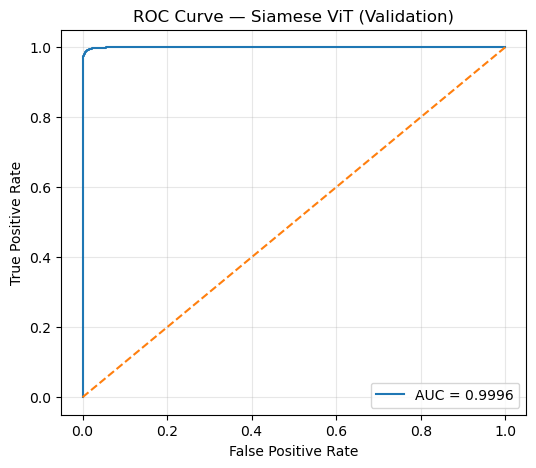

Saved ROC figure to: roc_curve_validation.png


In [38]:
# =================================
# ROC CURVE (FROM CACHE) + SAVE
# =================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

OUT_FIG = "roc_curve_validation.png"

assert "eval_cache" in globals(), "eval_cache not found. Run the evaluation (Cell 1) first."

y_true  = eval_cache["y_true"].astype(int)
y_score = eval_cache["y_score"]

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

print(f"ROC-AUC (val): {roc_auc:.4f}")

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Siamese ViT (Validation)")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

# plt.tight_layout()
plt.savefig(OUT_FIG, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved ROC figure to: {OUT_FIG}")


Overall accuracy @ thr=0.50: 0.9878  (n=2698)

Per-cell-type accuracy:
  A: acc=1.0000  (n=1322)
  B: acc=0.9968  (n=632)
  C: acc=0.9917  (n=242)
  D: acc=0.8353  (n=85)
  E: acc=0.9130  (n=46)
  F: acc=0.9877  (n=162)
  G: acc=0.9569  (n=209)


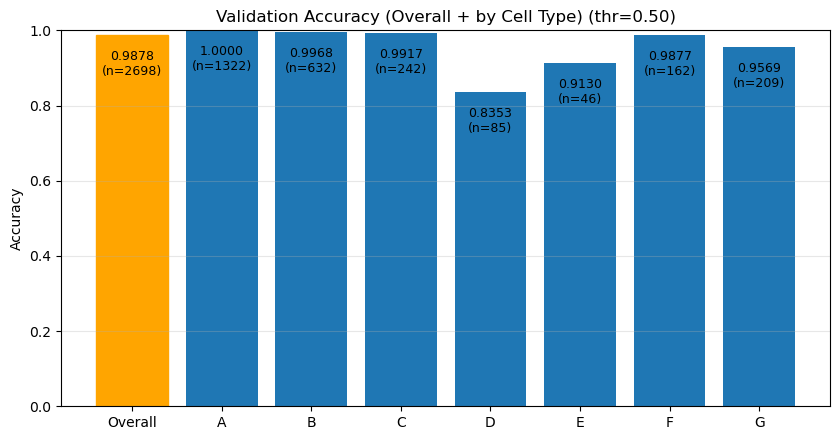


Saved accuracy plot to: accuracy_by_celltype_with_overall_thr_0.50.png


In [49]:
# # ======================================
# # ACCURACY (FROM CACHED RESULTS) + SAVE
# # ======================================
# import numpy as np
# import matplotlib.pyplot as plt

# THRESH = 0.5
# OUT_FIG = f"accuracy_by_celltype_thr_{THRESH:.2f}.png"

# assert "eval_cache" in globals(), "eval_cache not found. Run the evaluation cell first."

# y_true  = eval_cache["y_true"].astype(int)
# y_score = eval_cache["y_score"]
# letters = eval_cache["letters"]

# y_pred = (y_score >= THRESH).astype(int)

# # Overall accuracy
# acc_overall = (y_pred == y_true).mean()
# print(f"Overall accuracy @ thr={THRESH:.2f}: {acc_overall:.4f}  (n={len(y_true)})")

# # Per-cell-type accuracy
# letters_to_show = [k for k in list("ABCDEFG") if np.any(letters == k)]
# if np.any(letters == "Other"):
#     letters_to_show.append("Other")

# accs = []
# ns = []
# print("\nPer-cell-type accuracy:")
# for L in letters_to_show:
#     m = (letters == L)
#     n = int(m.sum())
#     acc = (y_pred[m] == y_true[m]).mean() if n > 0 else float("nan")
#     accs.append(acc)
#     ns.append(n)
#     print(f"  {L}: acc={acc:.4f}  (n={n})")

# # Plot with labels inside bars
# fig, ax = plt.subplots(figsize=(7.5, 4.5))
# bars = ax.bar(letters_to_show, accs)

# ax.set_ylim(0, 1)
# ax.set_ylabel("Accuracy")
# ax.set_title(f"Validation Accuracy by Cell Type (thr={THRESH:.2f})")
# ax.grid(True, axis="y", alpha=0.3)

# for bar, acc, n in zip(bars, accs, ns):
#     h = bar.get_height()
#     label = f"{acc:.4f}\n(n={n})"
#     # Place near the top INSIDE the bar; if bar is too short, place just above it
#     if h >= 0.12:
#         y_text = h - 0.04
#         va = "top"
#     else:
#         y_text = h + 0.02
#         va = "bottom"
#     ax.text(bar.get_x() + bar.get_width()/2, y_text, label,
#             ha="center", va=va, fontsize=9)

# plt.tight_layout()
# plt.savefig(OUT_FIG, dpi=300, bbox_inches="tight")
# plt.show()

# print(f"\nSaved accuracy plot to: {OUT_FIG}")


# ======================================
# ACCURACY (FROM CACHED RESULTS) + OVERALL BAR (DIFF COLOR) + SAVE
# ======================================
import numpy as np
import matplotlib.pyplot as plt

THRESH = 0.5
OUT_FIG = f"accuracy_by_celltype_with_overall_thr_{THRESH:.2f}.png"

assert "eval_cache" in globals(), "eval_cache not found. Run the evaluation cell first."

y_true  = eval_cache["y_true"].astype(int)
y_score = eval_cache["y_score"]
letters = eval_cache["letters"]

y_pred = (y_score >= THRESH).astype(int)

# Overall accuracy
acc_overall = (y_pred == y_true).mean()
n_overall = len(y_true)
print(f"Overall accuracy @ thr={THRESH:.2f}: {acc_overall:.4f}  (n={n_overall})")

# Per-cell-type accuracy
letters_to_show = [k for k in list("ABCDEFG") if np.any(letters == k)]
if np.any(letters == "Other"):
    letters_to_show.append("Other")

accs, ns = [], []
print("\nPer-cell-type accuracy:")
for L in letters_to_show:
    m = (letters == L)
    n = int(m.sum())
    acc = (y_pred[m] == y_true[m]).mean() if n > 0 else float("nan")
    accs.append(acc)
    ns.append(n)
    print(f"  {L}: acc={acc:.4f}  (n={n})")

# Add Overall bar at left
labels = ["Overall"] + letters_to_show
vals   = [acc_overall] + accs
counts = [n_overall] + ns

# Plot with labels inside bars
fig, ax = plt.subplots(figsize=(8.5, 4.5))
bars = ax.bar(labels, vals)

# Make the first bar a different color
bars[0].set_color("orange")

ax.set_ylim(0, 1)
ax.set_ylabel("Accuracy")
ax.set_title(f"Validation Accuracy (Overall + by Cell Type) (thr={THRESH:.2f})")
ax.grid(True, axis="y", alpha=0.3)

for bar, acc, n in zip(bars, vals, counts):
    h = bar.get_height()
    label = f"{acc:.4f}\n(n={n})"
    if h >= 0.12:
        y_text = h - 0.04
        va = "top"
    else:
        y_text = h + 0.02
        va = "bottom"
    ax.text(bar.get_x() + bar.get_width()/2, y_text, label,
            ha="center", va=va, fontsize=9)

plt.tight_layout()
plt.savefig(OUT_FIG, dpi=300, bbox_inches="tight")
plt.show()

print(f"\nSaved accuracy plot to: {OUT_FIG}")


Overall @ thr=0.50:
  TN=1382 FP=7 FN=26 TP=1283
  accuracy=0.9878  precision=0.9946  recall=0.9801
  Confusion matrix [[TN, FP],[FN, TP]]:


<Figure size 400x400 with 0 Axes>

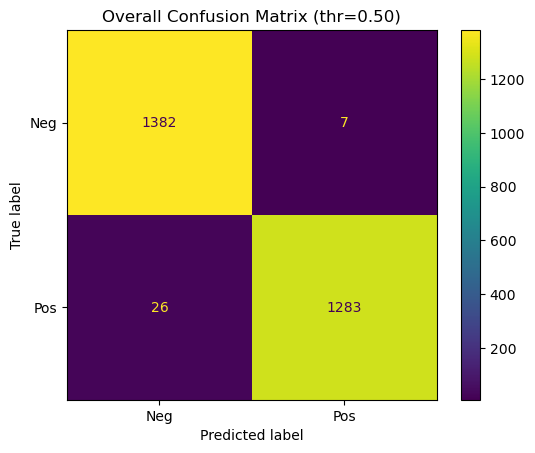


Per-cell-type confusion matrices:

A (n=1322)
  TN=730 FP=0 FN=0 TP=592
  accuracy=1.0000  precision=1.0000  recall=1.0000


<Figure size 400x400 with 0 Axes>

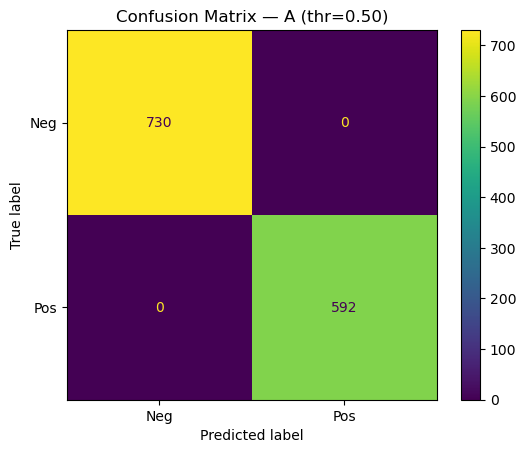


B (n=632)
  TN=301 FP=1 FN=1 TP=329
  accuracy=0.9968  precision=0.9970  recall=0.9970


<Figure size 400x400 with 0 Axes>

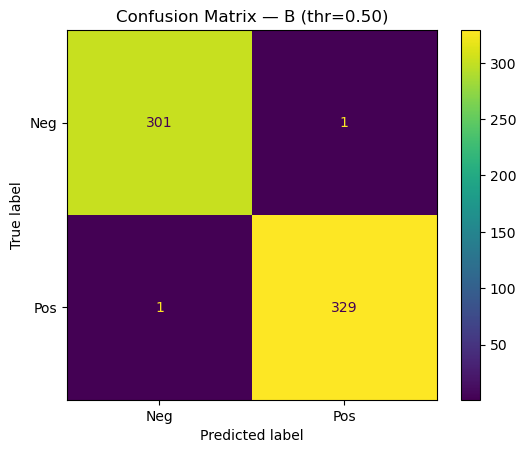


C (n=242)
  TN=102 FP=0 FN=2 TP=138
  accuracy=0.9917  precision=1.0000  recall=0.9857


<Figure size 400x400 with 0 Axes>

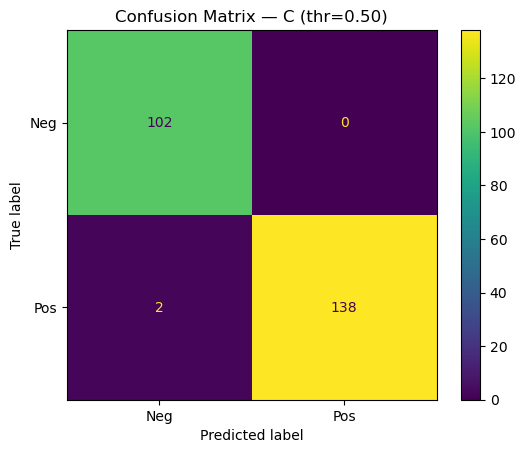


D (n=85)
  TN=22 FP=1 FN=13 TP=49
  accuracy=0.8353  precision=0.9800  recall=0.7903


<Figure size 400x400 with 0 Axes>

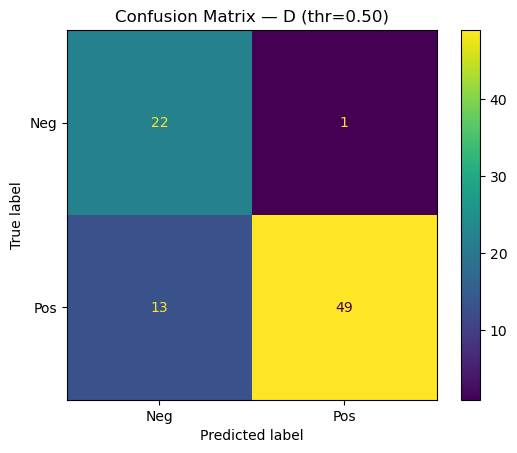


E (n=46)
  TN=36 FP=2 FN=2 TP=6
  accuracy=0.9130  precision=0.7500  recall=0.7500


<Figure size 400x400 with 0 Axes>

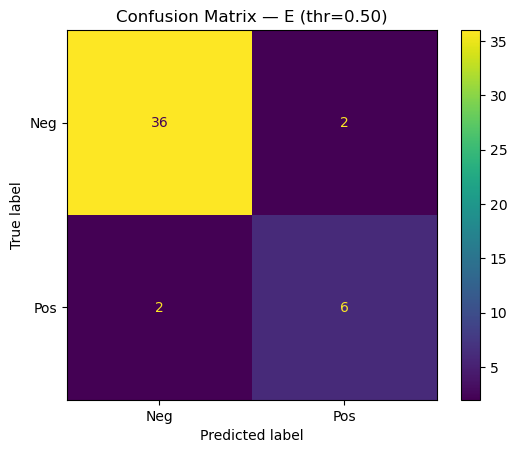


F (n=162)
  TN=125 FP=0 FN=2 TP=35
  accuracy=0.9877  precision=1.0000  recall=0.9459


<Figure size 400x400 with 0 Axes>

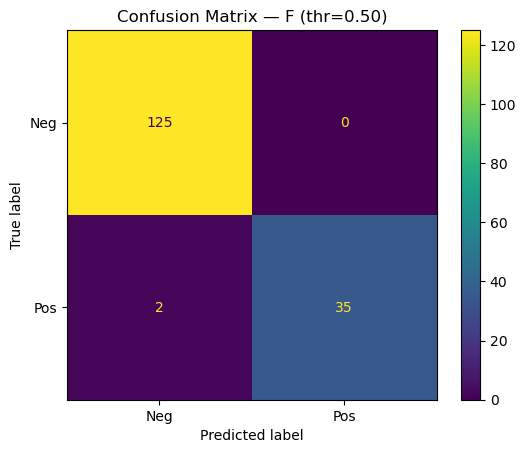


G (n=209)
  TN=66 FP=3 FN=6 TP=134
  accuracy=0.9569  precision=0.9781  recall=0.9571


<Figure size 400x400 with 0 Axes>

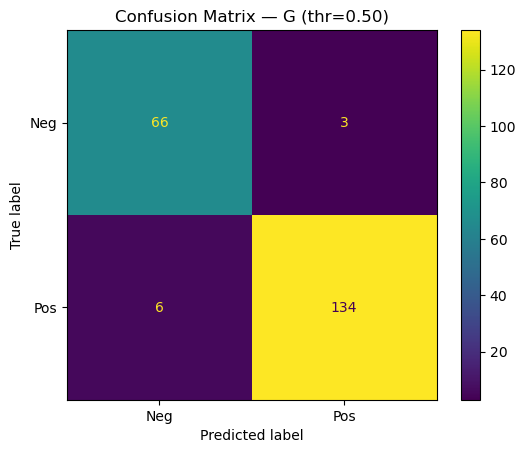

In [25]:
# ==================================================
# CONFUSION MATRICES (FROM CACHED RESULTS)
# ==================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

THRESH = 0.5

assert "eval_cache" in globals(), "eval_cache not found. Run Cell 1 first."

y_true  = eval_cache["y_true"].astype(int)
y_score = eval_cache["y_score"]
letters = eval_cache["letters"]

y_pred = (y_score >= THRESH).astype(int)

def cm_stats(cm):
    # cm = [[TN, FP],[FN, TP]]
    tn, fp, fn, tp = cm.ravel()
    total = tn + fp + fn + tp
    acc = (tn + tp) / total if total else float("nan")
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec  = tp / (tp + fn) if (tp + fn) else 0.0
    return tn, fp, fn, tp, acc, prec, rec

# ---- Overall confusion matrix ----
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
tn, fp, fn, tp, acc, prec, rec = cm_stats(cm)

print(f"Overall @ thr={THRESH:.2f}:")
print(f"  TN={tn} FP={fp} FN={fn} TP={tp}")
print(f"  accuracy={acc:.4f}  precision={prec:.4f}  recall={rec:.4f}")
print("  Confusion matrix [[TN, FP],[FN, TP]]:")

plt.figure(figsize=(4, 4))
ConfusionMatrixDisplay(cm, display_labels=["Neg", "Pos"]).plot(values_format="d")
plt.title(f"Overall Confusion Matrix (thr={THRESH:.2f})")
plt.grid(False)
plt.show()

# ---- Per-cell-type confusion matrices ----
letters_to_show = [k for k in list("ABCDEFG") if np.any(letters == k)]
if np.any(letters == "Other"):
    letters_to_show.append("Other")

print("\nPer-cell-type confusion matrices:")
for L in letters_to_show:
    m = (letters == L)
    yt = y_true[m]
    yp = y_pred[m]

    cmL = confusion_matrix(yt, yp, labels=[0, 1])
    tn, fp, fn, tp, acc, prec, rec = cm_stats(cmL)

    print(f"\n{L} (n={m.sum()})")
    print(f"  TN={tn} FP={fp} FN={fn} TP={tp}")
    print(f"  accuracy={acc:.4f}  precision={prec:.4f}  recall={rec:.4f}")

    plt.figure(figsize=(4, 4))
    ConfusionMatrixDisplay(cmL, display_labels=["Neg", "Pos"]).plot(values_format="d")
    plt.title(f"Confusion Matrix — {L} (thr={THRESH:.2f})")
    plt.grid(False)
    plt.show()


Overall @ thr=0.50:
  TN=1382 FP=7 FN=26 TP=1283
  accuracy=0.9878  precision=0.9946  recall=0.9801
  Confusion matrix [[TN, FP],[FN, TP]]:
[[1382    7]
 [  26 1283]]

Per-cell-type confusion matrices:

A (n=1322)
  TN=730 FP=0 FN=0 TP=592
  accuracy=1.0000  precision=1.0000  recall=1.0000
[[730   0]
 [  0 592]]

B (n=632)
  TN=301 FP=1 FN=1 TP=329
  accuracy=0.9968  precision=0.9970  recall=0.9970
[[301   1]
 [  1 329]]

C (n=242)
  TN=102 FP=0 FN=2 TP=138
  accuracy=0.9917  precision=1.0000  recall=0.9857
[[102   0]
 [  2 138]]

D (n=85)
  TN=22 FP=1 FN=13 TP=49
  accuracy=0.8353  precision=0.9800  recall=0.7903
[[22  1]
 [13 49]]

E (n=46)
  TN=36 FP=2 FN=2 TP=6
  accuracy=0.9130  precision=0.7500  recall=0.7500
[[36  2]
 [ 2  6]]

F (n=162)
  TN=125 FP=0 FN=2 TP=35
  accuracy=0.9877  precision=1.0000  recall=0.9459
[[125   0]
 [  2  35]]

G (n=209)
  TN=66 FP=3 FN=6 TP=134
  accuracy=0.9569  precision=0.9781  recall=0.9571
[[ 66   3]
 [  6 134]]


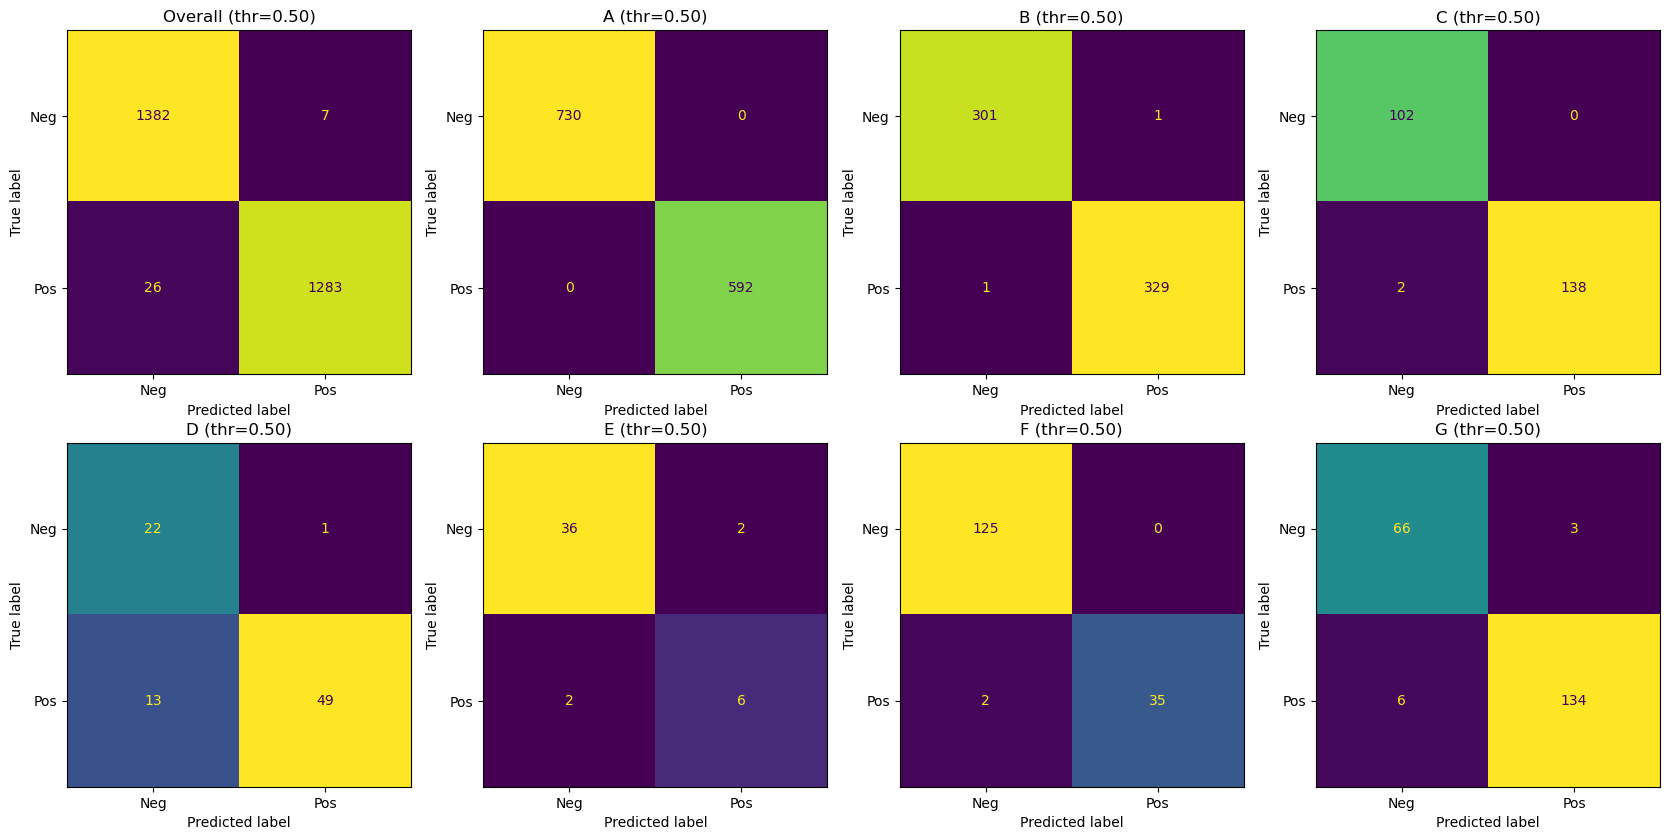


Saved confusion-matrix grid to: confusion_matrices_thr_0.50.png


In [27]:
# ==================================================
# CONFUSION MATRICES (GRID + SAVE) FROM CACHED RESULTS
# ==================================================
import math
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

THRESH = 0.5
OUT_FIG = f"confusion_matrices_thr_{THRESH:.2f}.png"  # saved in current working directory

assert "eval_cache" in globals(), "eval_cache not found. Run the evaluation cell first."

y_true  = eval_cache["y_true"].astype(int)
y_score = eval_cache["y_score"]
letters = eval_cache["letters"]

y_pred = (y_score >= THRESH).astype(int)

def cm_stats(cm):
    # cm = [[TN, FP],[FN, TP]]
    tn, fp, fn, tp = cm.ravel()
    total = tn + fp + fn + tp
    acc = (tn + tp) / total if total else float("nan")
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec  = tp / (tp + fn) if (tp + fn) else 0.0
    return tn, fp, fn, tp, acc, prec, rec

# ---- Decide which letters to show ----
letters_to_show = [k for k in list("ABCDEFG") if np.any(letters == k)]
if np.any(letters == "Other"):
    letters_to_show.append("Other")

# We'll plot: Overall + each letter
panel_names = ["Overall"] + letters_to_show

# ---- Print overall numeric results ----
cm_overall = confusion_matrix(y_true, y_pred, labels=[0, 1])
tn, fp, fn, tp, acc, prec, rec = cm_stats(cm_overall)

print(f"Overall @ thr={THRESH:.2f}:")
print(f"  TN={tn} FP={fp} FN={fn} TP={tp}")
print(f"  accuracy={acc:.4f}  precision={prec:.4f}  recall={rec:.4f}")
print("  Confusion matrix [[TN, FP],[FN, TP]]:")
print(cm_overall)

# ---- Print per-cell-type numeric results ----
print("\nPer-cell-type confusion matrices:")
cm_by_letter = {}  # store for plotting later

for L in letters_to_show:
    m = (letters == L)
    yt = y_true[m]
    yp = y_pred[m]

    cmL = confusion_matrix(yt, yp, labels=[0, 1])
    cm_by_letter[L] = cmL

    tn, fp, fn, tp, acc, prec, rec = cm_stats(cmL)

    print(f"\n{L} (n={m.sum()})")
    print(f"  TN={tn} FP={fp} FN={fn} TP={tp}")
    print(f"  accuracy={acc:.4f}  precision={prec:.4f}  recall={rec:.4f}")
    print(cmL)

# ---- Plot all confusion matrices in ONE figure (grid) ----
n_panels = len(panel_names)
ncols = 4
nrows = math.ceil(n_panels / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 4.2 * nrows))
axes = np.atleast_1d(axes).ravel()

def plot_cm(ax, cm, title):
    disp = ConfusionMatrixDisplay(cm, display_labels=["Neg", "Pos"])
    disp.plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(title)
    ax.grid(False)

# Panel 0: overall
plot_cm(axes[0], cm_overall, f"Overall (thr={THRESH:.2f})")

# Remaining: per letter
for i, L in enumerate(letters_to_show, start=1):
    plot_cm(axes[i], cm_by_letter[L], f"{L} (thr={THRESH:.2f})")

# Turn off any unused axes
for k in range(n_panels, len(axes)):
    axes[k].axis("off")

plt.tight_layout()
plt.savefig(OUT_FIG, dpi=300, bbox_inches="tight")
plt.show()

print(f"\nSaved confusion-matrix grid to: {OUT_FIG}")


In [42]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

thresholds = [round(t, 2) for t in np.arange(0.40, 1.001, 0.05)]

y_true  = np.asarray(eval_cache["y_true"]).astype(int)
y_score = np.asarray(eval_cache["y_score"])

rows = []
for thr in thresholds:
    y_pred = (y_score >= thr).astype(int)

    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])  # [[TN, FP],[FN, TP]]
    tn, fp, fn, tp = cm.ravel()
    acc = (tn + tp) / (tn + fp + fn + tp)

    rows.append((thr, prec, rec, f1, acc, tn, fp, fn, tp))

rows_sorted = sorted(rows, key=lambda x: (x[1], x[2]), reverse=True)
best = rows_sorted[0]

print("thr   precision  recall     f1        acc      TN   FP   FN   TP")
for (thr, prec, rec, f1, acc, tn, fp, fn, tp) in rows_sorted:
    print(f"{thr:0.1f}   {prec:0.4f}    {rec:0.4f}   {f1:0.4f}   {acc:0.4f}   {tn:4d} {fp:4d} {fn:4d} {tp:4d}")

print(f"\nBest (by precision, tie-break recall): thr={best[0]:0.1f}, precision={best[1]:0.4f}, recall={best[2]:0.4f}")


thr   precision  recall     f1        acc      TN   FP   FN   TP
1.0   1.0000    0.0023   0.0046   0.5159   1389    0 1306    3
0.9   0.9992    0.9641   0.9813   0.9822   1388    1   47 1262
0.9   0.9992    0.9542   0.9762   0.9774   1388    1   60 1249
0.8   0.9984    0.9710   0.9845   0.9852   1387    2   38 1271
0.8   0.9984    0.9672   0.9825   0.9833   1387    2   43 1266
0.8   0.9977    0.9740   0.9857   0.9863   1386    3   34 1275
0.6   0.9953    0.9794   0.9873   0.9878   1383    6   27 1282
0.7   0.9953    0.9771   0.9861   0.9867   1383    6   30 1279
0.7   0.9953    0.9763   0.9857   0.9863   1383    6   31 1278
0.5   0.9946    0.9801   0.9873   0.9878   1382    7   26 1283
0.5   0.9946    0.9801   0.9873   0.9878   1382    7   26 1283
0.6   0.9946    0.9794   0.9869   0.9874   1382    7   27 1282
0.4   0.9938    0.9840   0.9889   0.9893   1381    8   21 1288

Best (by precision, tie-break recall): thr=1.0, precision=1.0000, recall=0.0023


In [43]:
import numpy as np
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

y_true  = np.asarray(eval_cache["y_true"]).astype(int)
y_score = np.asarray(eval_cache["y_score"])

# Make sure thresholds exists; otherwise define a dense grid starting at 0.4
if "thresholds" not in globals():
    thresholds = [round(t, 2) for t in np.arange(0.40, 1.001, 0.02)]

def fbeta(p, r, beta=0.5):
    b2 = beta**2
    denom = (b2 * p + r)
    return 0.0 if denom == 0 else (1 + b2) * p * r / denom

rows = []
for thr in thresholds:
    y_pred = (y_score >= thr).astype(int)

    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)  # TPR
    f1 = f1_score(y_true, y_pred, zero_division=0)
    f05 = fbeta(p, r, beta=0.5)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])  # [[TN, FP],[FN, TP]]
    tn, fp, fn, tp = cm.ravel()

    fpr = fp / (fp + tn) if (fp + tn) else 0.0
    youden_j = r - fpr  # TPR - FPR

    rows.append({
        "thr": thr, "precision": p, "recall": r, "f1": f1, "f0.5": f05,
        "tn": tn, "fp": fp, "fn": fn, "tp": tp, "fpr": fpr, "youden_j": youden_j
    })

# Best thresholds
best_f05 = max(rows, key=lambda d: (d["f0.5"], d["precision"], d["recall"]))
best_j   = max(rows, key=lambda d: (d["youden_j"], d["recall"], d["precision"]))

def pretty(d):
    return (f"thr={d['thr']:.2f} | F0.5={d['f0.5']:.4f} | J={d['youden_j']:.4f} | "
            f"P={d['precision']:.4f} R={d['recall']:.4f} FPR={d['fpr']:.4f} | "
            f"TN={d['tn']} FP={d['fp']} FN={d['fn']} TP={d['tp']}")

print("Best threshold by F0.5 (precision-weighted):")
print(pretty(best_f05))

print("\nBest threshold by Youden's J (TPR - FPR):")
print(pretty(best_j))

# Optional: show confusion matrices for those thresholds
print("\nConfusion matrix @ best F0.5 (rows=true [0,1], cols=pred [0,1]):")
print(np.array([[best_f05["tn"], best_f05["fp"]],[best_f05["fn"], best_f05["tp"]]]))

print("\nConfusion matrix @ best Youden's J (rows=true [0,1], cols=pred [0,1]):")
print(np.array([[best_j["tn"], best_j["fp"]],[best_j["fn"], best_j["tp"]]]))


Best threshold by F0.5 (precision-weighted):
thr=0.75 | F0.5=0.9928 | J=0.9719 | P=0.9977 R=0.9740 FPR=0.0022 | TN=1386 FP=3 FN=34 TP=1275

Best threshold by Youden's J (TPR - FPR):
thr=0.40 | F0.5=0.9918 | J=0.9782 | P=0.9938 R=0.9840 FPR=0.0058 | TN=1381 FP=8 FN=21 TP=1288

Confusion matrix @ best F0.5 (rows=true [0,1], cols=pred [0,1]):
[[1386    3]
 [  34 1275]]

Confusion matrix @ best Youden's J (rows=true [0,1], cols=pred [0,1]):
[[1381    8]
 [  21 1288]]


Best F0.5 on grid: thr=0.730, F0.5=0.9932, P=0.9977, R=0.9756


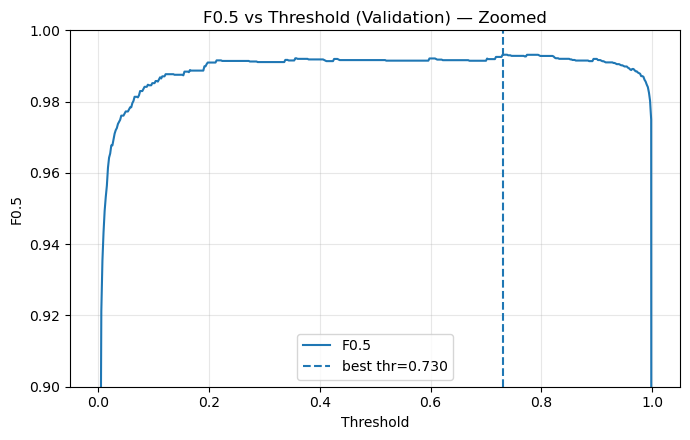

In [47]:
# =========================================
# Plot F0.5 vs threshold (zoomed y-axis: 0.9 -> 1.0)
# =========================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score

assert "eval_cache" in globals(), "eval_cache not found. Run the evaluation cell first."

y_true  = np.asarray(eval_cache["y_true"]).astype(int)
y_score = np.asarray(eval_cache["y_score"])

thr_grid = np.linspace(0.0, 1.0, 501)  # 0.002 step

def fbeta(p, r, beta=0.5):
    b2 = beta**2
    denom = (b2 * p + r)
    return 0.0 if denom == 0 else (1 + b2) * p * r / denom

f05_vals, prec_vals, rec_vals = [], [], []
for thr in thr_grid:
    y_pred = (y_score >= thr).astype(int)
    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    f05_vals.append(fbeta(p, r, beta=0.5))
    prec_vals.append(p)
    rec_vals.append(r)

f05_vals = np.array(f05_vals)

best_i = int(np.argmax(f05_vals))
best_thr = float(thr_grid[best_i])
best_f05 = float(f05_vals[best_i])

print(f"Best F0.5 on grid: thr={best_thr:.3f}, F0.5={best_f05:.4f}, "
      f"P={prec_vals[best_i]:.4f}, R={rec_vals[best_i]:.4f}")

plt.figure(figsize=(7, 4.5))
plt.plot(thr_grid, f05_vals, label="F0.5")
plt.axvline(best_thr, linestyle="--", label=f"best thr={best_thr:.3f}")
plt.xlabel("Threshold")
plt.ylabel("F0.5")
plt.title("F0.5 vs Threshold (Validation) — Zoomed")
plt.ylim(0.9, 1.0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



In [5]:
# ============================================
# EXPORT RAW DATA FOR ROC / ACCURACY / CONF-MAT
# (run AFTER the "EVAL ONCE (CACHE)" cell)
# ============================================
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve, confusion_matrix

THRESH = 0.5
OUT_ROC_CSV   = "roc_curve_validation.csv"
OUT_ACC_CSV   = f"accuracy_overall_and_by_celltype_thr_{THRESH:.2f}.csv"
OUT_CM_CSV    = f"confusion_matrices_overall_and_by_celltype_thr_{THRESH:.2f}.csv"
OUT_PRED_CSV  = f"val_predictions_raw_thr_{THRESH:.2f}.csv"   # optional but useful for re-plotting

assert "eval_cache" in globals(), "eval_cache not found. Run the evaluation cache cell first."

y_true  = np.asarray(eval_cache["y_true"]).astype(int)
y_score = np.asarray(eval_cache["y_score"])
letters = np.asarray(eval_cache["letters"])

# --------------------
# 1) ROC raw curve data
# --------------------
fpr, tpr, roc_thresholds = roc_curve(y_true, y_score, pos_label=1)
roc_df = pd.DataFrame({
    "fpr": fpr,
    "tpr": tpr,
    "threshold": roc_thresholds
})
roc_df.to_csv(OUT_ROC_CSV, index=False)
print(f"Saved ROC curve data -> {OUT_ROC_CSV}  (rows={len(roc_df)})")

# -----------------------------------
# 2) Accuracy (overall + per cell type)
# -----------------------------------
y_pred = (y_score >= THRESH).astype(int)

rows = []

# overall
rows.append({
    "group": "Overall",
    "threshold": THRESH,
    "n": int(len(y_true)),
    "accuracy": float((y_pred == y_true).mean())
})

# per cell-type
cell_types = [k for k in list("ABCDEFG") if np.any(letters == k)]
if np.any(letters == "Other"):
    cell_types.append("Other")

for ct in cell_types:
    m = (letters == ct)
    n = int(m.sum())
    acc = float((y_pred[m] == y_true[m]).mean()) if n > 0 else np.nan
    rows.append({
        "group": ct,
        "threshold": THRESH,
        "n": n,
        "accuracy": acc
    })

acc_df = pd.DataFrame(rows)
acc_df.to_csv(OUT_ACC_CSV, index=False)
print(f"Saved accuracy data -> {OUT_ACC_CSV}  (rows={len(acc_df)})")

# -----------------------------------------
# 3) Confusion matrices (overall + per type)
# -----------------------------------------
def cm_to_row(name, yt, yp):
    cm = confusion_matrix(yt, yp, labels=[0, 1])  # [[TN, FP],[FN, TP]]
    tn, fp, fn, tp = cm.ravel()
    total = tn + fp + fn + tp
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall    = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    accuracy  = (tn + tp) / total if total else np.nan
    return {
        "group": name,
        "threshold": THRESH,
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
        "n": int(total),
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "specificity": float(specificity),
    }

cm_rows = []
cm_rows.append(cm_to_row("Overall", y_true, y_pred))

for ct in cell_types:
    m = (letters == ct)
    cm_rows.append(cm_to_row(ct, y_true[m], y_pred[m]))

cm_df = pd.DataFrame(cm_rows)
cm_df.to_csv(OUT_CM_CSV, index=False)
print(f"Saved confusion-matrix data -> {OUT_CM_CSV}  (rows={len(cm_df)})")

# --------------------------------------------------------
# 4) OPTIONAL: per-sample raw predictions for any replotting
# --------------------------------------------------------
pred_df = pd.DataFrame({
    "y_true": y_true,
    "y_score": y_score,          # probability
    "y_pred": y_pred,            # thresholded at THRESH
    "cell_type": letters
})
pred_df.to_csv(OUT_PRED_CSV, index=False)
print(f"Saved raw per-sample predictions -> {OUT_PRED_CSV}  (rows={len(pred_df)})")

print("\nDone. Share these CSVs with the lab for unified plotting/styling.")


Saved ROC curve data -> roc_curve_validation.csv  (rows=176)
Saved accuracy data -> accuracy_overall_and_by_celltype_thr_0.50.csv  (rows=8)
Saved confusion-matrix data -> confusion_matrices_overall_and_by_celltype_thr_0.50.csv  (rows=8)
Saved raw per-sample predictions -> val_predictions_raw_thr_0.50.csv  (rows=2698)

Done. Share these CSVs with the lab for unified plotting/styling.


In [7]:
# ==========================================================
# EXPORT RAW DATA FOR: ROC, Accuracy bars, Confusion matrices
# (run AFTER the "EVAL ONCE (CACHE)" cell)
# ==========================================================
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve, auc, confusion_matrix

THRESH = 0.5

assert "eval_cache" in globals(), "eval_cache not found. Run the EVAL ONCE (CACHE) cell first."

y_true  = np.asarray(eval_cache["y_true"]).astype(int)
y_score = np.asarray(eval_cache["y_score"])
letters = np.asarray(eval_cache["letters"])

# ----------------------
# 1) ROC curve data CSV
# ----------------------
fpr, tpr, roc_thresholds = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

df_roc = pd.DataFrame({
    "fpr": fpr,
    "tpr": tpr,
    "threshold": roc_thresholds
})
df_roc["auc"] = roc_auc  # repeated column for convenience

roc_csv = "roc_curve_data_validation.csv"
df_roc.to_csv(roc_csv, index=False)
print(f"Saved ROC data to: {roc_csv} (AUC={roc_auc:.6f}, rows={len(df_roc)})")

# ---------------------------------------
# 2) Accuracy bar plot data CSV (thr=0.5)
# ---------------------------------------
y_pred = (y_score >= THRESH).astype(int)

overall_acc = float((y_pred == y_true).mean())
overall_n = int(len(y_true))

rows_acc = [{"group": "Overall", "accuracy": overall_acc, "n": overall_n, "threshold": THRESH}]

letters_to_show = [k for k in list("ABCDEFG") if np.any(letters == k)]
if np.any(letters == "Other"):
    letters_to_show.append("Other")

for L in letters_to_show:
    m = (letters == L)
    n = int(m.sum())
    acc = float((y_pred[m] == y_true[m]).mean()) if n > 0 else np.nan
    rows_acc.append({"group": L, "accuracy": acc, "n": n, "threshold": THRESH})

df_acc = pd.DataFrame(rows_acc)

acc_csv = f"accuracy_by_group_thr_{THRESH:.2f}.csv"
df_acc.to_csv(acc_csv, index=False)
print(f"Saved accuracy-bar data to: {acc_csv} (rows={len(df_acc)})")

# ------------------------------------------------
# 3) Confusion matrix data CSV (overall + A–G etc.)
# ------------------------------------------------
def cm_counts(yt, yp):
    cm = confusion_matrix(yt, yp, labels=[0, 1])  # [[TN, FP],[FN, TP]]
    tn, fp, fn, tp = cm.ravel()
    total = tn + fp + fn + tp
    acc = (tn + tp) / total if total else np.nan
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec  = tp / (tp + fn) if (tp + fn) else 0.0
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    fpr  = fp / (fp + tn) if (fp + tn) else 0.0
    return dict(tn=int(tn), fp=int(fp), fn=int(fn), tp=int(tp),
                n=int(total), accuracy=float(acc), precision=float(prec),
                recall=float(rec), specificity=float(spec), fpr=float(fpr))

rows_cm = []
rows_cm.append({"group": "Overall", "threshold": THRESH, **cm_counts(y_true, y_pred)})

for L in letters_to_show:
    m = (letters == L)
    rows_cm.append({"group": L, "threshold": THRESH, **cm_counts(y_true[m], y_pred[m])})

df_cm = pd.DataFrame(rows_cm)

cm_csv = f"confusion_matrices_by_group_thr_{THRESH:.2f}.csv"
df_cm.to_csv(cm_csv, index=False)
print(f"Saved confusion-matrix data to: {cm_csv} (rows={len(df_cm)})")

# ------------------------------------------------
# (Optional but often useful) sample-level outputs
# ------------------------------------------------
# Gives lab maximum flexibility to recompute any metric / plot later.
df_samples = pd.DataFrame({
    "y_true": y_true,
    "y_score": y_score,
    "y_pred_thr_0p50": y_pred,
    "group": letters
})
samples_csv = "sample_level_outputs_validation.csv"
df_samples.to_csv(samples_csv, index=False)
print(f"Saved sample-level outputs to: {samples_csv} (rows={len(df_samples)})")



Saved ROC data to: roc_curve_data_validation.csv (AUC=0.999626, rows=176)
Saved accuracy-bar data to: accuracy_by_group_thr_0.50.csv (rows=8)
Saved confusion-matrix data to: confusion_matrices_by_group_thr_0.50.csv (rows=8)
Saved sample-level outputs to: sample_level_outputs_validation.csv (rows=2698)
